# Modulation Complexity Score Implementation

In [2]:
from field import Field
import os

In [3]:
field = Field(os.path.dirname(os.getcwd()) + "\\Nov6\\" + "FieldID_2393324.json")

In [4]:
pos_a = field.matrixA
pos_b = field.matrixB

## Leaf Sequence Variability

In [5]:
pos_max_a = pos_a.max() - pos_a.min()
pos_max_b = pos_b.max() - pos_b.min()
n = pos_a.shape[0]

In [6]:
LSV_a = (pos_max_a - pos_a.diff()).sum()/((N)*pos_max_a)
LSV_b = (pos_max_b - pos_b.diff()).sum()/((N)*pos_max_b)

LSV_segment = LSV_a * LSV_b
LSV_segment

179    0.892415
177    0.892932
175    0.892393
173    0.893063
171    0.896042
         ...   
327    0.847096
325    0.847713
323    0.845159
321    0.840801
320    0.836224
Length: 111, dtype: float64

## Aperature Area Variability

In [7]:
AAV = (pos_a + pos_b).sum()/(pos_a.T.max() + pos_b.T.max()).sum()
AAV

179    0.157482
177    0.165903
175    0.164613
173    0.167778
171    0.174448
         ...   
327    0.395918
325    0.402772
323    0.401051
321    0.389710
320    0.386206
Length: 111, dtype: float64

In [8]:
MCS_beam = (AAV * LSV_segment * field.aperature_ms/field.beam_meterset).sum()
MCS_beam

0.15295380807875283

## MCS vs AD

In [9]:
def MCS(pos_a, pos_b, mu_weights):
    """
    Computes the modulation complexity score of a field

    Inputs
        pos_a (pandas DataFrame) - matrix of leaf bank A values
        pos_b (pandas DataFrame) - matrix of leaf bank B values
        mu_weights (pandas Series) - vector of metric units weights for each segment
    Returns
        mcs (float) - the modulation complexity score for the field
    """
    
    pos_max_a = pos_a.max() - pos_a.min()
    pos_max_b = pos_b.max() - pos_b.min()
    N = pos_a.shape[0]

    LSV_a = (pos_max_a - pos_a.diff()).sum()/((N)*pos_max_a)
    LSV_b = (pos_max_b - pos_b.diff()).sum()/((N)*pos_max_b)

    LSV_segment = LSV_a * LSV_b

    del LSV_a, LSV_b

    AAV = (pos_a + pos_b).sum()/(pos_a.T.max() + pos_b.T.max()).sum()

    mcs = (AAV * LSV_segment * mu_weights).sum()

    return mcs

In [10]:
import pandas as pd

df = pd.read_json(os.path.dirname(os.getcwd()) + "\\FieldsMetaData-2023-Nov-06.json")
directory = os.path.dirname(os.getcwd()) +'\\Nov6\\'
mcs = []
machine = []
for i in df["FieldID"]:
    file = directory+"FieldID_" + str(i) + '.json'
    field = Field(file)
    mcs.append(MCS(field.matrixA, field.matrixB, field.aperature_ms/field.beam_meterset))
    if field.machine_type == "Agility":
        machine.append("Elekta")
    else:
        machine.append("Varian")

df["Machine"] = machine
df["MCS"] = mcs

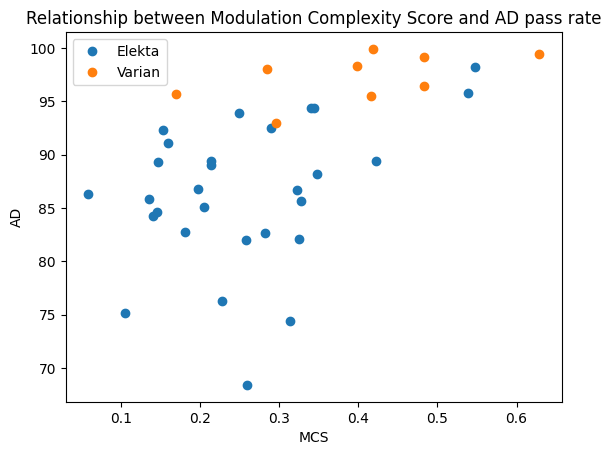

In [11]:
import matplotlib.pyplot as plt
groups = df.groupby('Machine')

# Plot
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.MCS, group.AD, marker='o', linestyle='', label=name)
ax.legend()
plt.xlabel("MCS")
plt.ylabel("AD")
plt.title("Relationship between Modulation Complexity Score and AD pass rate")
plt.show()